# Hoja de Trabajo 2 
## Reinforcement Learning
Francis Aguilar, 22243

José Marchena, 22398

---
## Task 1 (Entrega Parcial)

Responda las siguientes preguntas de forma clara, concisa y argumentada. No basta con definir, se espera que usted conecte el concepto con sus implicaciones prácticas o estratégicas.

### **1.** Elijan un sistema real que pueda modelarse como un k-armed bandit. Su modelado debe incluir:
> **Motor de recomendación de ejercicios en una app de aprendizaje de idiomas (tipo Duolingo)** En cada sesión el agente debe decidir qué ejercicio mostrarle a un usuario ahora mismo, sin conocer de antemano si ese ejercicio lo va a enganchar, aburrir o frustrar.

#### **1.1** Definición formal de los *k* brazos: qué representa cada acción y por qué el conjunto de acciones es finito y discreto en este dominio.

Cada brazo `a ∈ {1, ..., k}` puede representar una combinación de (tema, tipo de ejercicio, nivel de dificultad) que el sistema puede ofrecer en el siguiente turno. Por ejemplo:

| a | Tema                   | Tipo de pregunta       | Dificultad       |
| -- | ---------------------- | ---------------------- | ---------------- |
| 1 | Vocabulario            | Opción múltiple        | Fácil            |
| 2 | Gramática (subjuntivo) | Completar espacio      | Difícil          |
| 3 | Comprensión auditiva   | Completar espacio      | Fácil            |
| 4 | Traducción libre       | Completar espacio      | Difícil          |
| 5 | Pronunciación          | Hablar en el micrófono | Nivel intermedio |


El conjunto es finito y discreto porque cada opción está organizada en unidades y tipos de ejercicio predefinidos. Por tanto cada combinación es una decisión cerrada, donde el agente elige entre un menú finito de "Próximo ejercicio".


#### **1.2** Diseño justificado de la función de recompensa: qué se mide, cómo se mide, y qué supuestos distribucionales son razonables para ese dominio. Si la recompensa no es gaussiana, arguméntenlo.

> Qué se mide:
una señal compuesta de engagement + desempeño, por ejemplo:
`R_t = w₁·(completó el ejercicio) + w₂·(tiempo antes de la proxima sesion)`
(conociendo el que se busca maximizar completación de ejercicios, y minimizar el tiempo de proxima sesión)

> Cómo se mide: 
vía eventos de la app (clic en "completar", apertura de la app al día siguiente), agregados por usuario y por brazo.

> Supuestos distribucionales:
La recompensa combina dos componentes de naturaleza distinta, y ninguna es gaussiana:

- El término de **completó el ejercicio** es una variable Bernoulli (0 o 1), acotada y discreta.
- El término de **tiempo antes de la próxima sesión** es una variable de duración (tiempo hasta que el usuario regresa), que es no negativa por definición y típicamente muestra una distribución con cola larga a la derecha (la mayoría de los usuarios regresan rápido, unos pocos tardan mucho o nunca regresan). Se podria aplicar normalizacion para mantener este valor en un rango manejable como 0 y 1, lo que nos podria dar una distribución como Tanh.

- Al combinar ambos términos en R_t, el resultado es una **mezcla de una variable binaria con una variable de cola larga**, es decir, una distribución bimodal y asimétrica, muy alejada de la campana simétrica que asume un modelo gaussiano. Por eso, para estimar *q*∗(a) se recurre a promedios empíricos (muestrales o con paso constante), sin asumir una forma paramétrica gaussiana de fondo.

#### **1.3** Análisis de estacionariedad: ¿los valores verdaderos *q*∗(*a*) cambian con el tiempo en este sistema? ¿En qué escala temporal? ¿Qué implicaciones tiene eso para el algoritmo de actualización?

Los valores verdaderos *q*∗(a) **no son estacionarios**, y cambian en al menos tres escalas temporales distintas:

- **Escala de minutos (dentro de una sesión):** el usuario se cansa o se frustra conforme avanza la sesión, por lo que su tolerancia a la dificultad y su probabilidad de completar un ejercicio cambian en tiempo real.
- **Escala de días/semanas:** el usuario **aprende**. Un brazo que antes generaba baja recompensa (porque el usuario fallaba y tardaba en volver) puede genuinamente mejorar su *q*∗(a) conforme el usuario domina el tema. Este es un cambio real, no ruido, y es justamente la señal que el sistema busca aprovechar.
- **Escala de meses:** cambios de motivación general (rachas, vacaciones, cambio de objetivo de aprendizaje) modifican qué tipo de ejercicio mantiene enganchado al usuario.

**Implicación para el algoritmo de actualización:** un promedio muestral clásico (paso 1/n) trataría la mejora real del usuario como si fuera ruido estadístico y diluiría la señal reciente entre todo el historial acumulado, retrasando la detección de que el usuario ya domina un brazo antes difícil. Esto justifica usar una **regla de actualización con paso constante α**, que pondera más las observaciones recientes y permite que Q_t(a) "siga" la curva de aprendizaje del usuario en vez de promediar todo su historial por igual.

#### **1.4** Identificación de restricciones de exploración: ¿hay costos económicos, de seguridad o regulatorios que limiten cuánto puede explorar el sistema?

- **Costo de frustración y abandono (churn):** explorar repetidamente con ejercicios demasiado difíciles puede hacer que el usuario cierre la app y no regrese — una recompensa muy negativa y potencialmente irreversible, ya que a diferencia de otros dominios, aquí se puede perder al usuario por completo, no solo una interacción puntual.
- **Costo de aburrimiento:** explorar solo con ejercicios fáciles para "jugar seguro" tampoco es válido, ya que reduce la satisfacción y limita el progreso real del usuario (su nota o nivel).
- **Restricción pedagógica (zona de desarrollo próximo):** no cualquier exploración es aceptable — conviene explorar cerca del nivel actual del usuario y no de forma uniforme sobre todo el espacio de dificultad, ya que un salto de dificultad demasiado grande no aporta información útil y sí aumenta el riesgo de frustración.
- **Restricción de tiempo de sesión:** las sesiones son cortas (minutos al día), por lo que hay pocas oportunidades diarias de "probar" un brazo con cada usuario — el presupuesto de exploración es limitado y cada tirada exploratoria tiene un costo de oportunidad alto.


### 2. Con base en el análisis anterior, propongan y justifiquen:
#### **2.1** La estrategia de selección de acción más apropiada para su dominio, con el valor concreto del hiperparámetro relevante (ε o *c*) y la justificación de ese valor.


Se propone **UCB (Upper Confidence Bound)** con **c = 1.5**, en lugar de ε-greedy.

La razón es que, dado el costo de frustración y abandono identificado en 1.4, no conviene explorar de forma aleatoria-uniforme como hace ε-greedy (que podría, con probabilidad ε, mostrarle a un usuario avanzado un ejercicio trivial o a un principiante uno absurdamente difícil, sin importar cuánta información ya se tiene sobre ese brazo). UCB en cambio explora de forma sistemática y decreciente: prioriza brazos con poca información (`N_t(a)` bajo) y reduce la exploración sobre brazos que ya han sido probados muchas veces, concentrando el riesgo exploratorio donde realmente aporta información nueva.

Fórmula: `A_t = argmax_a [Q_t(a) + c·√(ln t / N_t(a))]`

Se elige **c = 1.5** como valor moderado: suficiente para cubrir el cold start con ~5 brazos disponibles en las primeras sesiones, pero no tan alto como para insistir en ejercicios difíciles ya fallidos varias veces solo por falta de datos, lo cual —dado el riesgo de churn— sería costoso. Valores típicos para bandits con recompensa acotada en [0,1] rondan c ∈ [1, 2]; 1.5 es un punto medio conservador.

#### **2.2** La regla de actualización de estimaciones (paso variable o constante) con justificación ligada al análisis de estacionariedad.
   
Dado que en 1.3 se estableció que el entorno **no es estacionario** (el usuario aprende y cambia su motivación con el tiempo), se usa una regla de **paso constante**:

`Q_{n+1}(a) = Q_n(a) + α · (R_n − Q_n(a))`, con **α = 0.15**

Se elige un α relativamente alto (comparado con un promedio muestral clásico) porque el número de observaciones por usuario y por brazo es limitado (pocas repeticiones de cada tipo de ejercicio por semana), por lo que conviene que Q_t(a) reaccione rápido a cada nueva observación y capture la curva de aprendizaje del usuario sin esperar muchas repeticiones para "confiar" en el cambio.


#### **2.3** Un ejemplo numérico con al menos seis observaciones que ilustre cómo evoluciona *Q*ₜ(*a*) para dos acciones distintas bajo la regla elegida, mostrando cómo la estimación converge o se adapta.

Comparamos dos brazos para un mismo usuario: **A1 (Gramática — difícil)** y **A2 (Vocabulario — fácil)**, con Q₀ = 0.5 (valor neutro inicial) y α = 0.15. La recompensa R_t ∈ [0,1] combina completó el ejercicio y qué tan rápido regresó a la siguiente sesión, en 6 sesiones sucesivas:

**Acción A1 (Gramática difícil)**

| t | R_t | Q_t antes | Q_{t+1} = Q_t + 0.15(R_t − Q_t) |
|---|------|-----------|--------------------------------|
| 1 | 0.2  | 0.500     | 0.455 |
| 2 | 0.3  | 0.455     | 0.432 |
| 3 | 0.6  | 0.432     | 0.457 |
| 4 | 0.7  | 0.457     | 0.494 |
| 5 | 0.8  | 0.494     | 0.539 |
| 6 | 0.9  | 0.539     | 0.594 |

**Acción A2 (Vocabulario fácil)**

| t | R_t | Q_t antes | Q_{t+1} = Q_t + 0.15(R_t − Q_t) |
|---|------|-----------|--------------------------------|
| 1 | 0.9  | 0.500     | 0.560 |
| 2 | 0.8  | 0.560     | 0.596 |
| 3 | 0.7  | 0.596     | 0.622 |
| 4 | 0.5  | 0.622     | 0.604 |
| 5 | 0.4  | 0.604     | 0.573 |
| 6 | 0.3  | 0.573     | 0.532 |

**Lectura del resultado:**

En **A1**, Q_t parte bajo (el usuario falla y tarda en regresar al principio) pero crece consistentemente de 0.455 a 0.594: refleja que el usuario aprende con la práctica, y el paso constante permite que la estimación siga esa mejora real sin diluirla entre los primeros intentos fallidos.

En **A2**, Q_t parte alto pero decrece de 0.596 a 0.532: el ejercicio deja de generar el mismo engagement porque el usuario ya lo domina y empieza a aburrirse — justo el riesgo de "mantener los ejercicios muy simples" que se buscaba evitar.

Hacia t=6, ambos valores convergen en un rango similar (0.53–0.59). En ese punto, UCB —al tener probablemente menos observaciones acumuladas sobre A1 por haber sido explorado con más cautela— seguiría asignándole cierto peso exploratorio adicional, empujando gradualmente al usuario hacia contenido más desafiante sin abandonar el refuerzo de vocabulario por completo. Esto es exactamente el comportamiento buscado: subir la dificultad progresivamente sin generar frustración excesiva ni estancarse en lo trivial.

----

## Task 2 (Entrega Final)

Realice y responda:

1. Implementen en Python un simulador de k-armed bandit con las tres estrategias vistas en clase: greedy puro, epsilon-greedy y UCB1. Su implementación debe incluir:
   1. Una clase `KArmedBandit` con soporte para modo estacionario y no estacionario. En modo no estacionario, los valores *q*∗(*a*) deben perturbarse cada cierto número de pasos configurable.
   2. Una clase por cada estrategia con métodos `select_action` y `update`, implementando la regla incremental con soporte para paso variable y paso constante.
   3. Un loop de experimento que corra al menos 500 episodios independientes de 1000 pasos, calculando recompensa promedio por paso y regret acumulado.
   4. Cuatro gráficas: recompensa promedio y regret acumulado en el entorno estacionario, y las mismas dos métricas en el entorno no estacionario.



In [11]:
import numpy as np
import matplotlib.pyplot as plt

K = 10            
N_EPISODES = 500  # episodios independientes
N_STEPS = 1000    # pasos por episodio

In [12]:

# Crear el entorno
def crear_bandit(k=10, seed=None):
    rng = np.random.default_rng(seed)
    q_star = rng.normal(0, 1, k)
    t = 0
    return rng, q_star, t


# Ejecutar una acción
def step(rng, q_star, t, action,
         stationary=True,
         drift_std=0.01,
         change_every=1,
         reward_std=1.0):

    # Valor óptimo antes de actualizar
    best = np.max(q_star)

    # Generar recompensa
    reward = rng.normal(q_star[action], reward_std)

    # Regret
    regret = best - q_star[action]

    # Actualizar contador
    t += 1

    # Si el entorno es no estacionario, aplicar random walk
    if not stationary and t % change_every == 0:
        q_star += rng.normal(0, drift_std, len(q_star))

    return reward, regret, q_star, t


In [13]:

# Inicializar estimaciones
def inicializar(k, valor_inicial=0):
    Q = np.full(k, valor_inicial, dtype=float)
    N = np.zeros(k, dtype=int)
    t = 0
    return Q, N, t


# Estrategia Greedy
def greedy(Q):
    return np.argmax(Q)


# Estrategia ε-Greedy
def epsilon_greedy(Q, epsilon, rng):
    if rng.random() < epsilon:
        return rng.integers(len(Q))
    return np.argmax(Q)


# Estrategia UCB1
def ucb(Q, N, t, c):
    # Probar cada brazo al menos una vez
    if np.any(N == 0):
        return np.argmin(N)

    valores = Q + c * np.sqrt(np.log(t) / N)
    return np.argmax(valores)


# Actualizar estimaciones
def actualizar(Q, N, t, accion, recompensa, step_size=None):
    N[accion] += 1
    t += 1

    if step_size is None:
        alpha = 1 / N[accion]
    else:
        alpha = step_size

    Q[accion] += alpha * (recompensa - Q[accion])

    return Q, N, t

In [14]:

def run_experiment(strategy, k=10, n_episodes=500, n_steps=1000,
                   stationary=True, drift_std=0.01,
                   change_every=1, seed=0, **params):

    rewards = np.zeros((n_episodes, n_steps))
    regrets = np.zeros((n_episodes, n_steps))

    master_rng = np.random.default_rng(seed)

    for ep in range(n_episodes):

        rng_bandit, q_star, t_bandit = crear_bandit(
            k, seed=int(master_rng.integers(1_000_000_000))
        )

        rng_strategy = np.random.default_rng(
            int(master_rng.integers(1_000_000_000))
        )

        Q, N, t = inicializar(k)

        regret_acumulado = 0

        for paso in range(n_steps):

            if strategy == "greedy":
                accion = greedy(Q)

            elif strategy == "epsilon":
                accion = epsilon_greedy(
                    Q, params["epsilon"], rng_strategy
                )

            elif strategy == "ucb":
                accion = ucb(
                    Q, N, max(t, 1), params["c"]
                )

            recompensa, regret, q_star, t_bandit = step(
                rng_bandit,
                q_star,
                t_bandit,
                accion,
                stationary=stationary,
                drift_std=drift_std,
                change_every=change_every,
            )

            Q, N, t = actualizar(Q, N, t, accion, recompensa, step_size=params.get("step_size"))

            rewards[ep, paso] = recompensa
            regret_acumulado += regret
            regrets[ep, paso] = regret_acumulado

    return rewards.mean(axis=0), regrets.mean(axis=0)

In [15]:
#experimento principal: entorno estacionario

strategies = [
    ("Greedy", {"strategy": "greedy"}),
    ("ε-Greedy (ε=0.1)", {"strategy": "epsilon", "epsilon": 0.1}),
    ("UCB1 (c=2)", {"strategy": "ucb", "c": 2})
]

results_stationary = {}

for i, (name, params) in enumerate(strategies):

    avg_r, avg_regret = run_experiment(
        k=K,
        n_episodes=N_EPISODES,
        n_steps=N_STEPS,
        stationary=True,
        seed=100 + i,
        **params
    )

    results_stationary[name] = (avg_r, avg_regret)

    print(
        f"[Estacionario] {name}: "
        f"Recompensa promedio = {avg_r[-50:].mean():.3f}, "
        f"Regret final = {avg_regret[-1]:.2f}"
    )

[Estacionario] Greedy: Recompensa promedio = 1.034, Regret final = 518.98
[Estacionario] ε-Greedy (ε=0.1): Recompensa promedio = 1.367, Regret final = 233.97
[Estacionario] UCB1 (c=2): Recompensa promedio = 1.460, Regret final = 151.02


In [16]:
# experimento principal: entorno no estacionario

strategies = [
    ("Greedy (α=0.1)", {"strategy": "greedy", "step_size": 0.1}),
    ("ε-Greedy (ε=0.1, α=0.1)", {"strategy": "epsilon", "epsilon": 0.1, "step_size": 0.1}),
    ("UCB1 (c=2, α=0.1)", {"strategy": "ucb", "c": 2, "step_size": 0.1})
]

results_nonstationary = {}

for i, (name, params) in enumerate(strategies):

    avg_r, avg_regret = run_experiment(
        k=K,
        n_episodes=N_EPISODES,
        n_steps=N_STEPS,
        stationary=False,
        drift_std=0.01,
        change_every=1,
        seed=200 + i,
        **params
    )

    results_nonstationary[name] = (avg_r, avg_regret)

    print(
        f"[No estacionario] {name}: "
        f"Recompensa promedio = {avg_r[-50:].mean():.3f}, "
        f"Regret final = {avg_regret[-1]:.2f}"
    )

[No estacionario] Greedy (α=0.1): Recompensa promedio = 1.294, Regret final = 310.57
[No estacionario] ε-Greedy (ε=0.1, α=0.1): Recompensa promedio = 1.443, Regret final = 301.70
[No estacionario] UCB1 (c=2, α=0.1): Recompensa promedio = 1.472, Regret final = 271.34


In [ ]:
# Las 4 gráficas requeridas: recompensa promedio y regret acumulado,
# en entorno estacionario y no estacionario

fig, axes = plt.subplots(2, 2, figsize=(13, 9))

for name, (avg_r, avg_regret) in results_stationary.items():
    axes[0, 0].plot(avg_r, label=name)
    axes[0, 1].plot(avg_regret, label=name)

axes[0, 0].set_title("Entorno estacionario — Recompensa promedio")
axes[0, 0].set_xlabel("Paso")
axes[0, 0].set_ylabel("Recompensa promedio")
axes[0, 0].legend()

axes[0, 1].set_title("Entorno estacionario — Regret acumulado")
axes[0, 1].set_xlabel("Paso")
axes[0, 1].set_ylabel("Regret acumulado")
axes[0, 1].legend()

for name, (avg_r, avg_regret) in results_nonstationary.items():
    axes[1, 0].plot(avg_r, label=name)
    axes[1, 1].plot(avg_regret, label=name)

axes[1, 0].set_title("Entorno no estacionario — Recompensa promedio")
axes[1, 0].set_xlabel("Paso")
axes[1, 0].set_ylabel("Recompensa promedio")
axes[1, 0].legend()

axes[1, 1].set_title("Entorno no estacionario — Regret acumulado")
axes[1, 1].set_xlabel("Paso")
axes[1, 1].set_ylabel("Regret acumulado")
axes[1, 1].legend()

plt.tight_layout()
plt.show()

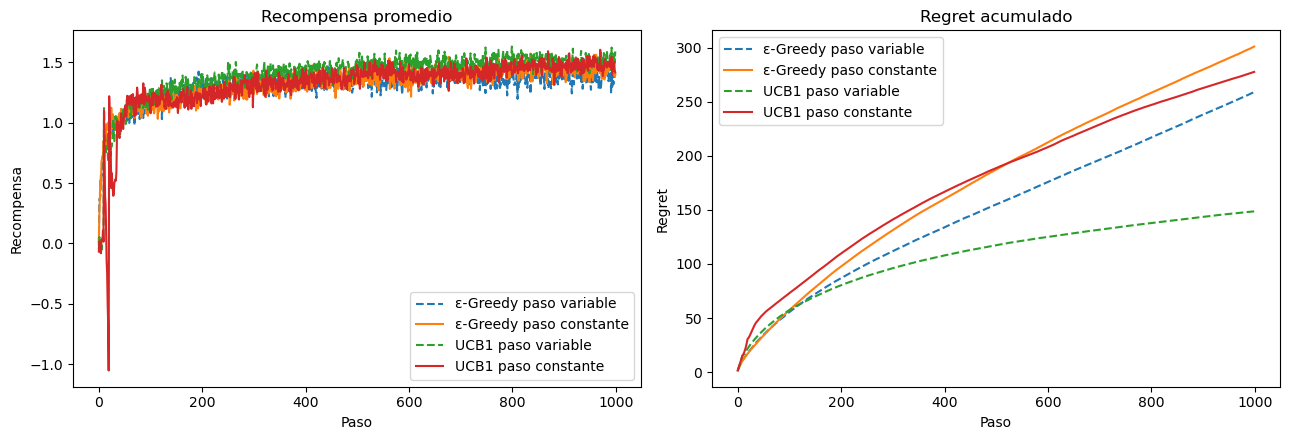

ε-Greedy paso variable: Regret final = 258.88
ε-Greedy paso constante: Regret final = 300.92
UCB1 paso variable: Regret final = 148.60
UCB1 paso constante: Regret final = 277.49


In [17]:
strategies = [
    ("ε-Greedy paso variable", {"strategy": "epsilon", "epsilon": 0.1}),
    ("ε-Greedy paso constante", {"strategy": "epsilon", "epsilon": 0.1, "step_size": 0.1}),
    ("UCB1 paso variable", {"strategy": "ucb", "c": 2}),
    ("UCB1 paso constante", {"strategy": "ucb", "c": 2, "step_size": 0.1})
]

results_step_comparison = {}

for i, (name, params) in enumerate(strategies):

    avg_r, avg_regret = run_experiment(
        k=K,
        n_episodes=N_EPISODES,
        n_steps=N_STEPS,
        stationary=False,
        drift_std=0.01,
        change_every=1,
        seed=300 + i,
        **params
    )

    results_step_comparison[name] = (avg_r, avg_regret)


# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

for name, (avg_r, avg_regret) in results_step_comparison.items():

    estilo = "--" if "variable" in name else "-"

    axes[0].plot(avg_r, estilo, label=name)
    axes[1].plot(avg_regret, estilo, label=name)

axes[0].set_title("Recompensa promedio")
axes[0].set_xlabel("Paso")
axes[0].set_ylabel("Recompensa")
axes[0].legend()

axes[1].set_title("Regret acumulado")
axes[1].set_xlabel("Paso")
axes[1].set_ylabel("Regret")
axes[1].legend()

plt.tight_layout()
plt.show()


# Mostrar regret final
for name, (_, avg_regret) in results_step_comparison.items():
    print(f"{name}: Regret final = {avg_regret[-1]:.2f}")

ε = 0.01: Regret final = 329.51
ε = 0.05: Regret final = 195.17
ε = 0.1: Regret final = 233.97
ε = 0.3: Regret final = 510.46
c = 0.5: Regret final = 58.01
c = 1.0: Regret final = 57.72
c = 2.0: Regret final = 148.41
c = 4.0: Regret final = 374.56


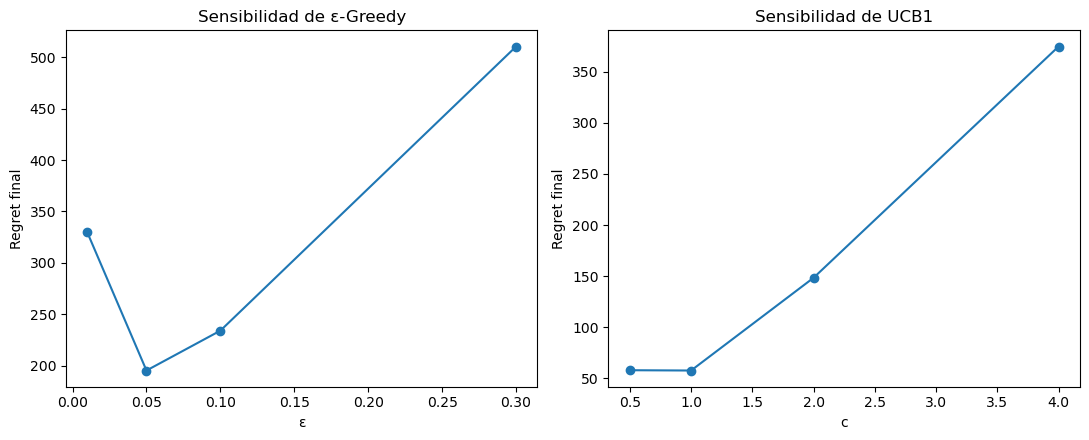

In [18]:
epsilons = [0.01, 0.05, 0.1, 0.3]
cs = [0.5, 1.0, 2.0, 4.0]

# Sensibilidad de ε-greedy
epsilon_final_regret = []

for eps in epsilons:

    _, avg_regret = run_experiment(
        strategy="epsilon",
        epsilon=eps,
        k=K,
        n_episodes=N_EPISODES,
        n_steps=N_STEPS,
        stationary=True,
        seed=int(eps * 1000) + 1
    )

    epsilon_final_regret.append(avg_regret[-1])
    print(f"ε = {eps}: Regret final = {avg_regret[-1]:.2f}")


# Sensibilidad de UCB1
c_final_regret = []

for c in cs:

    _, avg_regret = run_experiment(
        strategy="ucb",
        c=c,
        k=K,
        n_episodes=N_EPISODES,
        n_steps=N_STEPS,
        stationary=True,
        seed=int(c * 1000) + 1
    )

    c_final_regret.append(avg_regret[-1])
    print(f"c = {c}: Regret final = {avg_regret[-1]:.2f}")


# Graficar resultados
fig, axes = plt.subplots(1, 2, figsize=(11, 4.5))

axes[0].plot(epsilons, epsilon_final_regret, marker="o")
axes[0].set_title("Sensibilidad de ε-Greedy")
axes[0].set_xlabel("ε")
axes[0].set_ylabel("Regret final")

axes[1].plot(cs, c_final_regret, marker="o")
axes[1].set_title("Sensibilidad de UCB1")
axes[1].set_xlabel("c")
axes[1].set_ylabel("Regret final")

plt.tight_layout()
plt.show()

2. Con base en los resultados de la implementación:
   1. Analicen el comportamiento del regret acumulado de cada estrategia en el entorno estacionario. ¿La jerarquía entre estrategias coincide con lo esperado teóricamente? ¿A partir de qué paso el regret de UCB comienza a diferenciarse del de epsilon-greedy?

   Los resultados muestran que UCB1 obtuvo el menor regret acumulado, seguido de ε-greedy y, por último, Greedy. Este orden coincide con la teoría, ya que Greedy deja de explorar muy pronto y puede quedarse usando una acción que no es la mejor. En cambio, ε-greedy sigue explorando de vez en cuando, mientras que UCB1 equilibra mejor la exploración y la explotación.

   Durante los primeros pasos las tres estrategias tienen un comportamiento parecido, porque todavía están aprendiendo cuál es el mejor brazo. Aproximadamente después del paso 200, la curva de UCB1 comienza a crecer más lentamente que la de ε-greedy, mostrando una ventaja clara al reducir el regret acumulado.
   

   2. Analicen qué ocurre en el entorno no estacionario. ¿Qué estrategia se adapta mejor? ¿Cómo cambia el resultado al usar paso constante versus paso variable?


   En el entorno no estacionario, UCB1 volvió a obtener el mejor resultado, seguido por ε-greedy y luego Greedy. Esto indica que UCB1 también logra adaptarse mejor cuando las recompensas cambian con el tiempo.

   Al comparar el paso constante con el paso variable, el paso variable obtuvo mejores resultados en este experimento. Esto ocurrió porque los cambios en el entorno fueron pequeños y el paso variable permitió obtener estimaciones más estables. En estas condiciones, el paso constante introdujo más variación sin ofrecer una ventaja importante.

   3. Realicen un análisis de sensibilidad: corran epsilon-greedy con al menos tres valores distintos de ε y UCB con al menos tres valores de *c*. Grafiquen el regret final en función del hiperparámetro y discutan cuál rango de valores es más robusto.

   En ε-greedy, el mejor resultado se obtuvo con ε = 0.05. Cuando ε fue muy pequeño (0.01), la estrategia exploró muy poco y aumentó el regret. Cuando ε fue muy grande (0.3), exploró demasiado y también empeoró el rendimiento. Por ello, un rango entre 0.05 y 0.1 fue el más adecuado.

   En UCB1, los mejores resultados se obtuvieron con c = 0.5 y c = 1.0. Valores mayores hicieron que la estrategia explorara más de lo necesario, aumentando el regret. Por esta razón, el rango entre 0.5 y 1.0 fue el más robusto.



   4. Cierren con una sección de diseño aplicado: tomando los resultados anteriores, ¿qué configuración específica recomendarían para el sistema real que modelaron en la entrega parcial? Justifiquen la recomendación con evidencia de sus experimentos, no solo con argumentos teóricos.


   Con base en los resultados, la mejor opción para el sistema es utilizar UCB1, ya que fue la estrategia con menor regret tanto en el entorno estacionario como en el no estacionario. Además, el análisis de sensibilidad mostró que funciona mejor con un valor de c entre 0.5 y 1.0.

   Para la actualización de los valores, se recomienda usar paso variable (1/N) cuando los cambios del entorno sean pequeños, ya que en los experimentos obtuvo mejores resultados. Si en el sistema real las preferencias de los usuarios cambian con mayor rapidez, entonces un paso constante podría ser una mejor alternativa para adaptarse más rápido.




NOTA


Se utilizó inteligencia artificial como herramienta de apoyo para la generación y refactorización de partes del código en Python. Las sugerencias proporcionadas sirvieron como base para la implementación y simplificación de algunas funciones, las cuales fueron revisadas, comprendidas y adaptadas manualmente para cumplir con los requisitos de la práctica. La IA se empleó como un asistente de desarrollo y aprendizaje, mientras que la integración, validación y análisis de los resultados fueron realizados por el estudiante